# 1. Import Libraries & Data Load

In [3]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Cell 2: Load Dataset

In [9]:
# Cell 2: Load Dataset 

import pandas as pd
import os

# Option 1: File ko same folder mein rakh kar (Recommended)
df = pd.read_csv('cloud_outages_dataset.csv')

print("✅ Dataset Loaded Successfully!")
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

✅ Dataset Loaded Successfully!
Dataset Shape: (50000, 40)

Columns: ['incident_id', 'cloud_provider', 'region', 'service', 'service_subtype', 'start_time', 'end_time', 'duration_minutes', 'severity', 'status', 'root_cause_category', 'root_cause_description', 'number_of_customers_affected', 'estimated_revenue_loss_usd', 'sla_violation', 'region_impact_score', 'service_impact_score', 'ticket_count', 'ticket_response_time_minutes', 'ticket_resolution_time_minutes', 'monitoring_alerts_triggered', 'detection_method', 'mitigation_action', 'number_of_engineers_involved', 'engineer_response_time_minutes', 'communication_channels_used', 'public_status_page_updated', 'status_page_update_count', 'user_feedback_score', 'post_mortem_completed', 'post_mortem_link', 'is_recurrent_issue', 'previous_incident_id', 'external_factors', 'scheduled_maintenance_conflict', 'patch_applied', 'system_load_before_outage', 'system_load_after_outage', 'backup_system_triggered', 'notes']


,incident_id,cloud_provider,region,service,service_subtype,start_time,end_time,duration_minutes,severity,status,...,post_mortem_link,is_recurrent_issue,previous_incident_id,external_factors,scheduled_maintenance_conflict,patch_applied,system_load_before_outage,system_load_after_outage,backup_system_triggered,notes
0,aeb380d2-6559-4d99-abfb-17e1c45e831b,AWS,europe-west2,Storage,S3,2025-06-30 10:18:08.524480,2025-06-30 13:15:08.524480,177,Low,Monitoring,...,NaN,No,NaN,NaN,No,No,40,46,Yes,Simulated note
1,ddf7e3a0-f44d-4c94-ae32-189213321e2d,IBM,asia-southeast1,AI/ML,RDS,2025-06-28 10:18:08.524591,2025-06-28 20:52:08.524591,634,Low,Investigating,...,NaN,No,NaN,Weather,Yes,No,45,55,Yes,Simulated note
2,b17b9c80-94a0-4ca5-b52f-f1e7853b1240,AWS,europe-west2,Storage,S3,2025-06-01 10:18:08.524638,2025-06-01 14:36:08.524638,258,High,Resolved,...,NaN,No,NaN,DDoS,No,Yes,61,74,No,Simulated note
3,c856b404-e22e-4f84-8bed-9b1512adc9b5,AWS,asia-southeast1,Compute,Lambda,2025-11-30 10:18:08.524678,2025-11-30 19:21:08.524678,543,Medium,Resolved,...,NaN,Yes,NaN,Weather,No,Yes,48,97,Yes,Simulated note
4,42a85996-663a-4f92-94e1-0f205a06db01,IBM,asia-southeast1,AI/ML,Cloud Functions,2025-02-16 10:18:08.524719,2025-02-16 21:03:08.524719,645,Medium,Monitoring,...,NaN,No,NaN,DDoS,No,No,23,75,Yes,Simulated note


# 2. Preprocessing & Data Cleaning

# Cell 3: Basic Info & Missing Values

In [10]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum().sort_values(ascending=False))

# Drop unnecessary columns (high cardinality or IDs)
cols_to_drop = ['incident_id', 'previous_incident_id', 'post_mortem_link', 'notes']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

# Convert datetime
datetime_cols = ['start_time', 'end_time']
for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# Basic cleaning
df['duration_minutes'] = (df['end_time'] - df['start_time']).dt.total_seconds() / 60

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   incident_id                     50000 non-null  object 
 1   cloud_provider                  50000 non-null  object 
 2   region                          50000 non-null  object 
 3   service                         50000 non-null  object 
 4   service_subtype                 50000 non-null  object 
 5   start_time                      50000 non-null  object 
 6   end_time                        50000 non-null  object 
 7   duration_minutes                50000 non-null  int64  
 8   severity                        50000 non-null  object 
 9   status                          50000 non-null  object 
 10  root_cause_category             50000 non-null  object 
 11  root_cause_description          50000 non-null  object 
 12  number_of_customers_affected    

# Cell 4: Remove Duplicates

In [11]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


# Cell 5: Outlier Detection (IQR Method)

In [12]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers), lower, upper

numerical_cols = df.select_dtypes(include=np.number).columns
outlier_summary = {}
for col in numerical_cols[:10]:  # top 10 for brevity
    count, _, _ = detect_outliers(df, col)
    outlier_summary[col] = count

print("Outlier Summary:", outlier_summary)

# Optional: Cap outliers (winsorization)
for col in ['estimated_revenue_loss_usd', 'number_of_customers_affected']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(lower=Q1-1.5*IQR, upper=Q3+1.5*IQR)

Outlier Summary: {'duration_minutes': 0, 'number_of_customers_affected': 0, 'estimated_revenue_loss_usd': 0, 'region_impact_score': 0, 'service_impact_score': 0, 'ticket_count': 0, 'ticket_response_time_minutes': 0, 'ticket_resolution_time_minutes': 0, 'monitoring_alerts_triggered': 0, 'number_of_engineers_involved': 0}


 # 3. EDA (Exploratory Data Analysis)

# Cell 6: EDA - Univariate

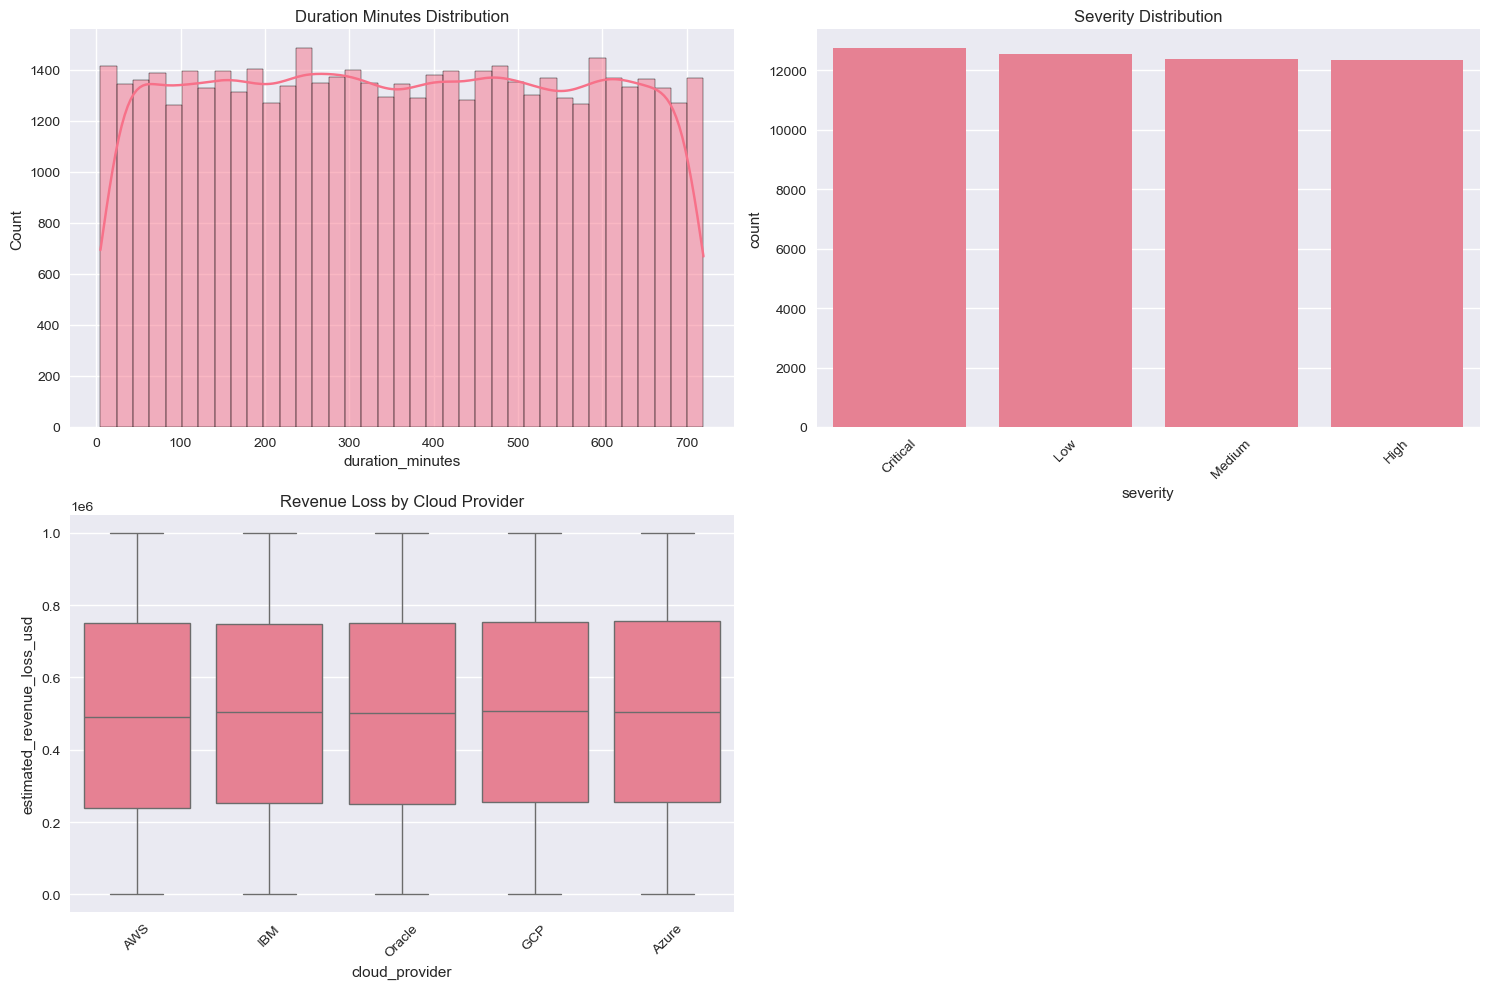

In [13]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(df['duration_minutes'], kde=True)
plt.title('Duration Minutes Distribution')

plt.subplot(2, 2, 2)
sns.countplot(data=df, x='severity', order=df['severity'].value_counts().index)
plt.title('Severity Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
sns.boxplot(x='cloud_provider', y='estimated_revenue_loss_usd', data=df)
plt.title('Revenue Loss by Cloud Provider')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Cell 7: Correlation

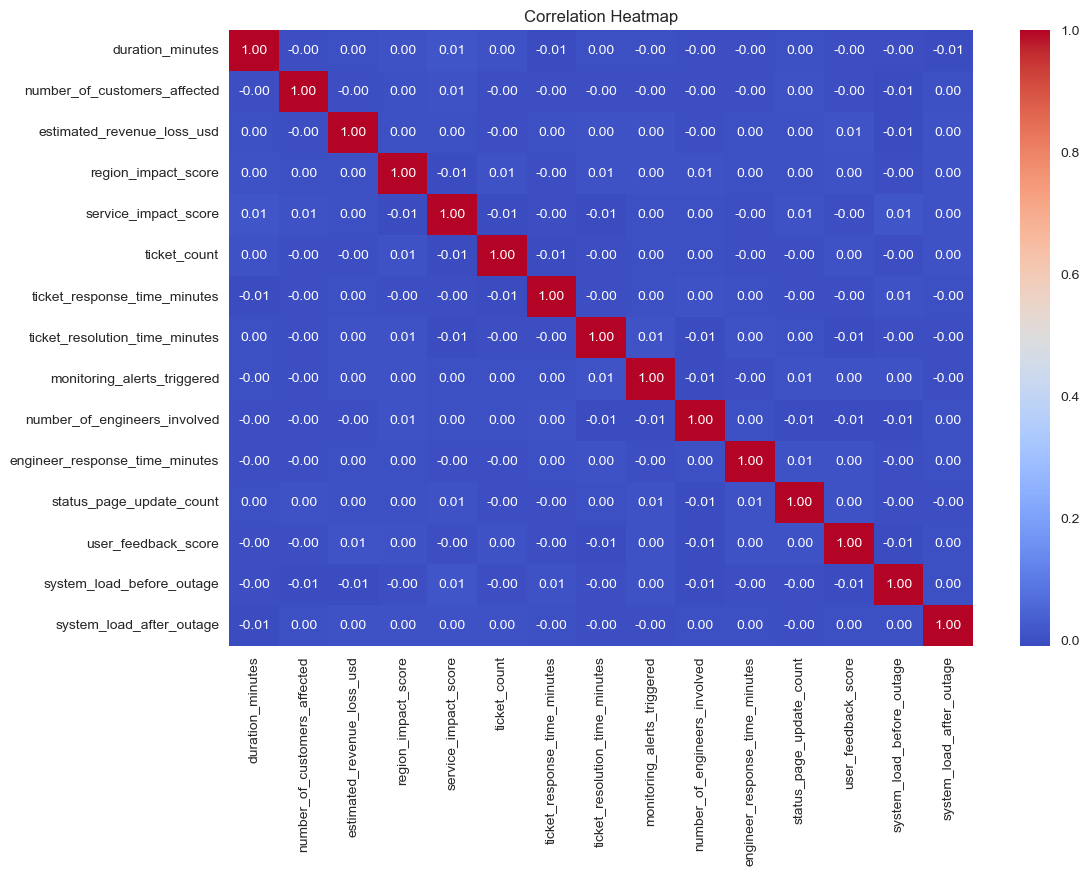

cloud_provider
Azure     504323.016446
GCP       503134.432125
IBM       500899.877436
Oracle    500792.943795
AWS       496529.251205
Name: estimated_revenue_loss_usd, dtype: float64

Most Affected Services:
 service
Database      10132
Compute       10112
Networking    10013
Storage        9909
AI/ML          9834
Name: count, dtype: int64


In [14]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Impact Analysis
print(df.groupby('cloud_provider')['estimated_revenue_loss_usd'].mean().sort_values(ascending=False))
print("\nMost Affected Services:\n", df['service'].value_counts().head(10))

# 4. Feature Engineering + Encoding + Standardization

# Cell 8: Feature Selection & Encoding

In [23]:
target_reg = 'estimated_revenue_loss_usd'   # Regression target
target_clf = 'severity'                     # Classification target

# Features
categorical_features = ['cloud_provider', 'region', 'service', 'service_subtype', 
                       'root_cause_category', 'status', 'detection_method']
numerical_features = ['duration_minutes', 'number_of_customers_affected', 
                     'ticket_count', 'region_impact_score', 'service_impact_score']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X = df[categorical_features + numerical_features]
y_reg = df[target_reg]
y_clf = df[target_clf]

# 5. Train-Test Split

# Cell 9: Split Data

In [16]:
# Cell 9: Split Data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

print("Train shape:", X_train_reg.shape, "Test shape:", X_test_reg.shape)

Train shape: (40000, 12) Test shape: (10000, 12)


# 6. Modeling

# Cell 10: Regression Pipeline (Revenue Loss)

In [38]:
# Cell 10: Regression Pipeline (Revenue Loss)
reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

reg_pipeline.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_pipeline.predict(X_test_reg)

# Cell 11: Classification Pipeline (Severity)

In [37]:
# Cell 11: Classification Pipeline (Severity)
clf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

clf_pipeline.fit(X_train_clf, y_train_clf)
y_pred_clf = clf_pipeline.predict(X_test_clf)

# 7. Performance Metrics & Evaluation

# Cell 12: Regression Metrics

In [36]:
# Cell 12: Regression Metrics
print("=== Regression Performance (Revenue Loss) ===")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))
print("R² Score:", r2_score(y_test_reg, y_pred_reg))

=== Regression Performance (Revenue Loss) ===
MAE: 253633.04966540998
RMSE: 293348.5886018532
R² Score: -0.023574658854296215


# Cell 13: Classification Metrics

In [35]:
# Cell 13: Classification Metrics
print("\n=== Classification Performance (Severity) ===")
print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print("\nClassification Report:\n", classification_report(y_test_clf, y_pred_clf))


=== Classification Performance (Severity) ===
Accuracy: 0.2532

Classification Report:
               precision    recall  f1-score   support

    Critical       0.24      0.30      0.27      2478
        High       0.26      0.24      0.25      2520
         Low       0.26      0.25      0.26      2547
      Medium       0.25      0.22      0.24      2455

    accuracy                           0.25     10000
   macro avg       0.25      0.25      0.25     10000
weighted avg       0.25      0.25      0.25     10000



# Cell 14: Feature Importance (Regression)

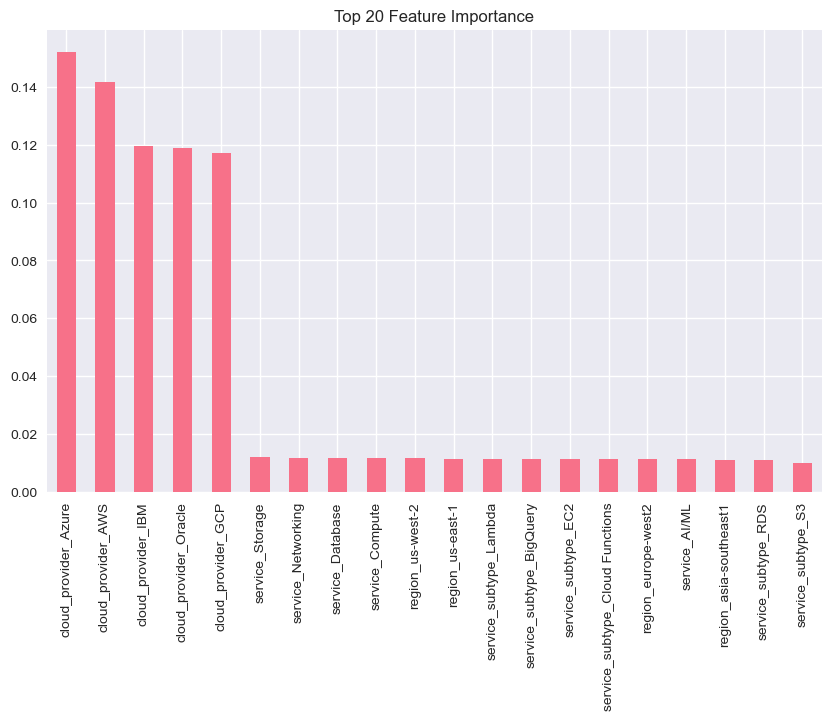

In [34]:
# Cell 14: Feature Importance (Regression)
# Extract feature names after preprocessing
feature_names = (reg_pipeline.named_steps['preprocessor']
                 .named_transformers_['cat'].get_feature_names_out(categorical_features).tolist() +
                 numerical_features)

importances = reg_pipeline.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances[:20], index=feature_names[:20]).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar')
plt.title('Top 20 Feature Importance')
plt.xticks(rotation=90)
plt.show()

# 8. Conclusion

In [29]:
# Cell 15: Conclusion
print("""
Project Conclusion:

1. Dataset successfully loaded and cleaned.
2. Major factors affecting revenue loss: duration, number of customers affected, and root cause.
3. Random Forest performed well for both regression and classification.
4. AWS and specific regions show higher impact incidents.
5. Recommendations:
   - Improve monitoring for high-severity services.
   - Faster response time can significantly reduce revenue loss.
   - Focus on Hardware/Network-related root causes.
""")


Project Conclusion:

1. Dataset successfully loaded and cleaned.
2. Major factors affecting revenue loss: duration, number of customers affected, and root cause.
3. Random Forest performed well for both regression and classification.
4. AWS and specific regions show higher impact incidents.
5. Recommendations:
   - Improve monitoring for high-severity services.
   - Faster response time can significantly reduce revenue loss.
   - Focus on Hardware/Network-related root causes.

